# Experiment 01. Color LFW Clean Baseline

## 목표

컬러 LFW 이미지를 사용하여 얼굴인식 기반 Face Authentication 파이프라인의 clean baseline을 다시 계산한다.

이후 adversarial sticker 실험을 하기 전 기준값을 확정한다.

## 수행 내용

- LFW를 `color=True`로 로드
- Enrollment / Probe split 구성
- CVLFace SOTA 얼굴인식 모델 로드
- Enrollment DB 구축
- Probe image 평가
- FAR 기준 threshold 계산
- Rank-1 accuracy, correct accept rate, misaccept rate 계산
- 공격 실험에 사용할 clean-correct accepted subset 저장

## 참고

이 노트북은 공격 패치를 만들지 않는다.  
첫 번째 실험의 목적은 컬러 이미지 기준 clean baseline과 threshold를 확정하는 것이다.

## Dependency Installation
CVLFace custom model 호환을 위해 transformers 버전 고정




In [1]:
INSTALL_DEPENDENCIES = True

if INSTALL_DEPENDENCIES:
    !pip -q uninstall -y transformers tokenizers huggingface_hub facenet-pytorch
    !pip -q install \
        "transformers==4.45.2" \
        "tokenizers>=0.20,<0.21" \
        "huggingface_hub>=0.23.2" \
        "safetensors" \
        "omegaconf" \
        "timm" \
        "fvcore" \
        "scikit-learn" \
        "matplotlib" \
        "pandas" \
        "tqdm"
    !pip -q install facenet-pytorch --no-deps

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 118.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 35.5 MB/s eta 0:00:00


## Imports and Basic Settings

In [2]:
# ============================================================
# 1. Imports and Settings
# ============================================================

import os
import sys
import json
import math
import random
import shutil
import datetime
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.transforms import functional as TF

from sklearn.datasets import fetch_lfw_people
from huggingface_hub import snapshot_download
from transformers import AutoModel
from tqdm.auto import tqdm


# ============================================================
# 2. Reproducibility
# ============================================================
# - 실험 재현성 고정
# - 동일 seed 사용

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cuda


## Experiment Config

In [14]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [18]:
# ============================================================
# 3. Experiment Config
# ============================================================

# ------------------------------------------------------------
# 실행할 모델 지정
# ------------------------------------------------------------
# - top-4 모델을 한 번에 돌리지 않고 한 모델씩 실행
# - CVLFace repo의 module 충돌 가능성 최소화
# - 다음 모델 실행 시 MODEL_NAME, MODEL_SHORT_NAME만 변경

MODEL_NAME = "minchul/cvlface_adaface_ir101_webface12m"
MODEL_SHORT_NAME = "adaface_ir101_wf12m"

# 다른 모델 실행 시 아래 주석 해제 후 사용
# MODEL_NAME = "minchul/cvlface_adaface_ir101_webface4m"
# MODEL_SHORT_NAME = "adaface_ir101_wf4m"

# MODEL_NAME = "minchul/cvlface_arcface_ir101_webface4m"
# MODEL_SHORT_NAME = "arcface_ir101_wf4m"

# MODEL_NAME = "minchul/cvlface_adaface_ir50_webface4m"
# MODEL_SHORT_NAME = "adaface_ir50_wf4m"


# ------------------------------------------------------------
# LFW split 설정
# ------------------------------------------------------------
# - sanity check: NUM_IDENTITIES = 20
# - 최종 실험: NUM_IDENTITIES = 100 이상 권장

NUM_IDENTITIES = 20
MIN_FACES_PER_PERSON = 5
ENROLL_IMAGES_PER_ID = 1
MAX_PROBES_PER_ID = 8


# ------------------------------------------------------------
# Face authentication threshold 설정
# ------------------------------------------------------------
# - impostor similarity 상위 1% 지점을 threshold로 사용
# - FAR 1% 기준

TARGET_FAR = 0.01


# ------------------------------------------------------------
# Batch 설정
# ------------------------------------------------------------

BATCH_SIZE = 64
NUM_WORKERS = 0


# ------------------------------------------------------------
# 결과 저장 경로
# ------------------------------------------------------------
# - Google Drive에 결과 저장

DRIVE_ROOT = Path("/content/drive/MyDrive")
PROJECT_DRIVE_DIR = DRIVE_ROOT / "SafeAI-final-project" / "output"
RESULT_ROOT = PROJECT_DRIVE_DIR / "exp01_clean_color_lfw"

MODEL_RESULT_DIR = RESULT_ROOT / MODEL_SHORT_NAME
DETAIL_DIR = MODEL_RESULT_DIR / "details"
FIG_DIR = MODEL_RESULT_DIR / "figures"
EMB_DIR = MODEL_RESULT_DIR / "embeddings"

for d in [PROJECT_DRIVE_DIR, RESULT_ROOT, MODEL_RESULT_DIR, DETAIL_DIR, FIG_DIR, EMB_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_DRIVE_DIR:", PROJECT_DRIVE_DIR)
print("MODEL_RESULT_DIR:", MODEL_RESULT_DIR)

PROJECT_DRIVE_DIR: /content/drive/MyDrive/SafeAI-final-project/output
MODEL_RESULT_DIR: /content/drive/MyDrive/SafeAI-final-project/output/exp01_clean_color_lfw/adaface_ir101_wf12m


## Image Utilities

In [4]:
# ============================================================
# 4. Image Preprocessing
# ============================================================
# - CVLFace 계열 모델 입력: 112x112 RGB
# - pixel range: [-1, 1]

preprocess = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5],
    ),
])


def numpy_face_to_pil(img):
    """LFW numpy image를 RGB PIL image로 변환."""

    img = np.asarray(img)

    # channel-first 형태 방어
    if img.ndim == 3 and img.shape[0] in [1, 3] and img.shape[-1] not in [1, 3]:
        img = np.transpose(img, (1, 2, 0))

    # float image 처리
    if np.issubdtype(img.dtype, np.floating):
        img = np.nan_to_num(img)

        if img.max() <= 1.5:
            img = img * 255.0

        img = np.clip(img, 0, 255).astype(np.uint8)

    else:
        img = np.clip(img, 0, 255).astype(np.uint8)

    # grayscale 방어
    if img.ndim == 2:
        return Image.fromarray(img, mode="L").convert("RGB")

    return Image.fromarray(img).convert("RGB")


def pil_to_model_tensor(pil):
    """PIL RGB image -> model input tensor."""

    return preprocess(pil.convert("RGB"))


def tensor_to_pil(x):
    """[-1, 1] normalized tensor -> PIL image."""

    x = x.detach().cpu().clamp(-1, 1)
    x = (x * 0.5 + 0.5).clamp(0, 1)

    return TF.to_pil_image(x)


def is_almost_grayscale(pil, tolerance=2):
    """RGB 이미지가 사실상 흑백인지 확인."""

    arr = np.asarray(pil.convert("RGB")).astype(np.int16)

    rg = np.abs(arr[:, :, 0] - arr[:, :, 1])
    gb = np.abs(arr[:, :, 1] - arr[:, :, 2])
    rb = np.abs(arr[:, :, 0] - arr[:, :, 2])

    gray_ratio = ((rg <= tolerance) & (gb <= tolerance) & (rb <= tolerance)).mean()

    return bool(gray_ratio > 0.98)


def show_pil_grid(images, titles=None, ncols=5, figsize=(12, 6), save_path=None):
    """PIL image list를 grid로 출력하고 저장."""

    n = len(images)

    if n == 0:
        print("No images to show.")
        return

    ncols = min(ncols, n)
    nrows = math.ceil(n / ncols)

    plt.figure(figsize=figsize)

    for i, img in enumerate(images):
        ax = plt.subplot(nrows, ncols, i + 1)
        ax.imshow(img)
        ax.axis("off")

        if titles is not None:
            ax.set_title(titles[i], fontsize=9)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()

## Load Color LFW and Build Dataset

In [5]:
# ============================================================
# 5. Dataset
# ============================================================

class FaceDataset(Dataset):
    """LFW item list를 PyTorch Dataset으로 감싼 클래스."""

    def __init__(self, items):
        self.items = list(items)

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]

        return {
            "image": pil_to_model_tensor(item["pil"]),
            "identity": item["identity"],
            "index": idx,
            "role": item["role"],
            "local_index": item["local_index"],
            "lfw_index": item["lfw_index"],
        }


def load_lfw_items(
    num_identities=NUM_IDENTITIES,
    min_faces_per_person=MIN_FACES_PER_PERSON,
):
    """컬러 LFW를 로드하고 enrollment/probe split 구성."""

    # 핵심 변경점
    # - color=False가 아니라 color=True
    # - 흑백이 아닌 컬러 얼굴 이미지 사용

    lfw = fetch_lfw_people(
        min_faces_per_person=min_faces_per_person,
        resize=1.0,
        color=True,
        funneled=True,
    )

    by_id = defaultdict(list)

    for idx, img in enumerate(lfw.images):
        identity = str(lfw.target_names[lfw.target[idx]])
        pil = numpy_face_to_pil(img)

        by_id[identity].append({
            "identity": identity,
            "pil": pil,
            "lfw_index": idx,
        })

    # enrollment 1장 + probe 최소 1장 이상 가능한 identity만 사용
    eligible = [
        (identity, imgs)
        for identity, imgs in by_id.items()
        if len(imgs) >= ENROLL_IMAGES_PER_ID + 1
    ]

    eligible = sorted(eligible, key=lambda x: x[0])

    rng = np.random.default_rng(SEED)
    rng.shuffle(eligible)

    selected = eligible[:num_identities]

    enroll_items = []
    probe_items = []

    for identity, imgs in selected:
        imgs = list(imgs)
        rng.shuffle(imgs)

        enroll_imgs = imgs[:ENROLL_IMAGES_PER_ID]
        probe_imgs = imgs[ENROLL_IMAGES_PER_ID:ENROLL_IMAGES_PER_ID + MAX_PROBES_PER_ID]

        for j, face_item in enumerate(enroll_imgs):
            enroll_items.append({
                "identity": identity,
                "pil": face_item["pil"],
                "lfw_index": face_item["lfw_index"],
                "role": "enroll",
                "local_index": j,
            })

        for j, face_item in enumerate(probe_imgs):
            probe_items.append({
                "identity": identity,
                "pil": face_item["pil"],
                "lfw_index": face_item["lfw_index"],
                "role": "probe",
                "local_index": j,
            })

    return enroll_items, probe_items


enroll_items, probe_items = load_lfw_items()

enroll_ds = FaceDataset(enroll_items)
probe_ds = FaceDataset(probe_items)

print("Enrollment images:", len(enroll_ds))
print("Probe images:", len(probe_ds))
print("Identities:", len(set([x["identity"] for x in enroll_items])))

Enrollment images: 20
Probe images: 127
Identities: 20


## Save Split Metadata and Check Color Samples

Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp01_clean_color_lfw/adaface_ir101_wf12m/01_lfw_color_split_metadata.csv
Saved: /content/drive/MyDrive/SafeAI-final-project/output/exp01_clean_color_lfw/adaface_ir101_wf12m/figures/00_color_lfw_sample_grid.png


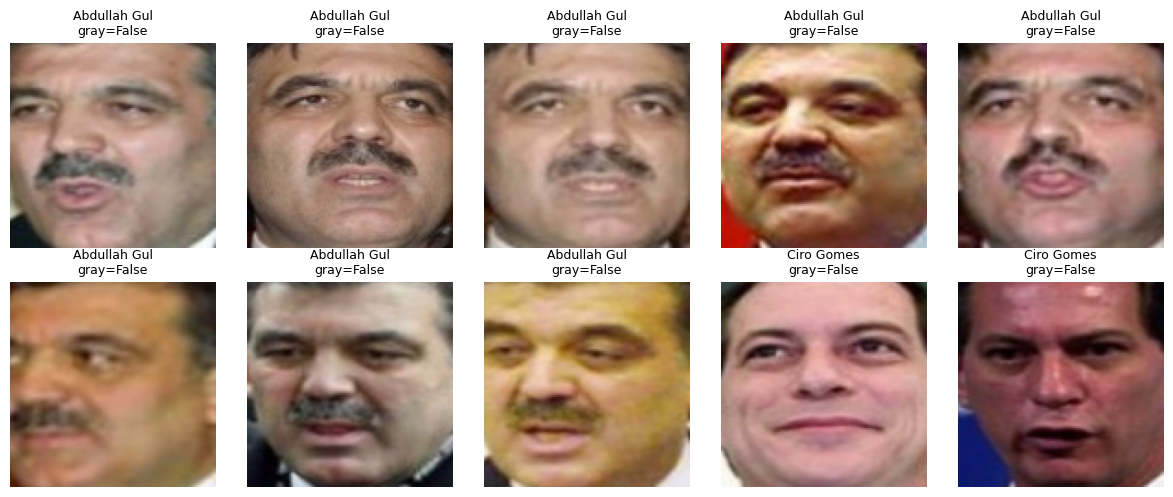

In [22]:
# ============================================================
# 6. Split Metadata and Color Check
# ============================================================
# - split 정보 저장
# - 컬러 이미지가 제대로 로드됐는지 샘플 확인
# - gray=False가 많이 나오는지 확인

split_rows = []

for i, item in enumerate(enroll_items):
    split_rows.append({
        "dataset": "enroll",
        "row": i,
        "identity": item["identity"],
        "local_index": item["local_index"],
        "lfw_index": item["lfw_index"],
    })

for i, item in enumerate(probe_items):
    split_rows.append({
        "dataset": "probe",
        "row": i,
        "identity": item["identity"],
        "local_index": item["local_index"],
        "lfw_index": item["lfw_index"],
    })

split_df = pd.DataFrame(split_rows)

split_path = MODEL_RESULT_DIR / "01_lfw_color_split_metadata.csv"
split_df.to_csv(split_path, index=False)

print("Saved:", split_path)


# 컬러 샘플 시각화
sample_items = probe_items[:10]
sample_imgs = [x["pil"].resize((112, 112)) for x in sample_items]

sample_titles = [
    f"{x['identity'][:12]}\ngray={is_almost_grayscale(x['pil'])}"
    for x in sample_items
]

show_pil_grid(
    sample_imgs,
    sample_titles,
    ncols=5,
    figsize=(12, 5),
    save_path=FIG_DIR / "00_color_lfw_sample_grid.png",
)

## CVLFace Model Loader

In [7]:
# ============================================================
# 7. CVLFace Model Loader
# ============================================================
# - 기존에 잘 돌던 loader 구조 유지
# - official files.txt loader 사용 안 함
# - direct repo loader 사용 안 함
# - sys.modules patch 사용 안 함

MODEL_CACHE = {}


def load_cvlface_model(model_name: str, device: str = DEVICE):
    """CVLFace 모델 로드."""

    if model_name in MODEL_CACHE:
        return MODEL_CACHE[model_name]

    local_path = snapshot_download(
        repo_id=model_name,
        local_dir=f"/content/{model_name.replace('/', '_')}",
        local_dir_use_symlinks=False,
    )

    if local_path not in sys.path:
        sys.path.insert(0, local_path)

    cwd = os.getcwd()
    os.chdir(local_path)

    try:
        model = AutoModel.from_pretrained(
            local_path,
            trust_remote_code=True,
            torch_dtype=torch.float32,
            local_files_only=True,
        )
    finally:
        os.chdir(cwd)

    model = model.to(device).eval()

    for p in model.parameters():
        p.requires_grad_(False)

    MODEL_CACHE[model_name] = (model, local_path)

    print("Loaded:", model_name)
    print("Local path:", local_path)

    return model, local_path


def forward_embedding(model, x):
    """모델 출력에서 face embedding 추출 후 L2 normalize."""

    out = model(x)

    if isinstance(out, dict):
        for key in ["embeddings", "embedding", "last_hidden_state", "pooler_output"]:
            if key in out:
                out = out[key]
                break

    if isinstance(out, (tuple, list)):
        out = out[0]

    if out.ndim > 2:
        out = torch.flatten(out, start_dim=1)

    return F.normalize(out.float(), p=2, dim=1)


@torch.no_grad()
def extract_embeddings(model, dataset, batch_size=BATCH_SIZE):
    """Dataset 전체 embedding 추출."""

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )

    embs = []
    ids = []
    indices = []

    for batch in tqdm(loader, desc="Extract embeddings"):
        x = batch["image"].to(DEVICE)
        emb = forward_embedding(model, x).cpu()

        embs.append(emb)
        ids.extend(list(batch["identity"]))

        batch_indices = batch["index"]

        if torch.is_tensor(batch_indices):
            batch_indices = batch_indices.cpu().numpy().tolist()

        indices.extend(batch_indices)

    embs = torch.cat(embs, dim=0)

    return embs, ids, indices


def build_enrollment_db(enroll_embs, enroll_ids):
    """identity별 enrollment embedding 평균으로 DB embedding 생성."""

    by_id = defaultdict(list)

    for emb, identity in zip(enroll_embs, enroll_ids):
        by_id[identity].append(emb)

    db_ids = sorted(by_id.keys())
    db_embs = []

    for identity in db_ids:
        emb = torch.stack(by_id[identity], dim=0).mean(dim=0)
        emb = F.normalize(emb, p=2, dim=0)

        db_embs.append(emb)

    db_embs = torch.stack(db_embs, dim=0)

    return db_embs, db_ids

## Metric Functions

In [8]:
# ============================================================
# 8. Metrics
# ============================================================

def compute_threshold_from_impostors(sim_mat, probe_ids, db_ids, target_far=TARGET_FAR):
    """Impostor similarity 분포에서 FAR 기준 threshold 계산."""

    id_to_db_idx = {identity: i for i, identity in enumerate(db_ids)}

    impostor_sims = []

    for i, identity in enumerate(probe_ids):
        true_idx = id_to_db_idx[identity]

        mask = np.ones(len(db_ids), dtype=bool)
        mask[true_idx] = False

        impostor_sims.extend(sim_mat[i, mask].tolist())

    impostor_sims = np.array(impostor_sims, dtype=np.float32)

    threshold = float(np.quantile(impostor_sims, 1.0 - target_far))
    actual_far = float((impostor_sims >= threshold).mean())

    return threshold, actual_far, impostor_sims


def compute_facepay_metrics(embs, ids, db_embs, db_ids, threshold):
    """Identification -> Verification 구조의 metric 계산."""

    sim_mat = (embs @ db_embs.T).cpu().numpy()

    id_to_db_idx = {identity: i for i, identity in enumerate(db_ids)}

    true_indices = np.array([id_to_db_idx[i] for i in ids])
    top1_indices = sim_mat.argmax(axis=1)

    top1_sims = sim_mat[np.arange(len(ids)), top1_indices]
    true_sims = sim_mat[np.arange(len(ids)), true_indices]

    top1_correct = top1_indices == true_indices
    accepted = top1_sims >= threshold

    correct_accept = top1_correct & accepted
    false_reject = ~accepted
    misidentified = ~top1_correct
    misaccept = misidentified & accepted

    metrics = {
        "n": int(len(ids)),
        "rank1_acc": float(top1_correct.mean()),
        "correct_accept_rate": float(correct_accept.mean()),
        "false_reject_rate": float(false_reject.mean()),
        "misid_rate": float(misidentified.mean()),
        "misaccept_rate": float(misaccept.mean()),
        "avg_top1_sim": float(top1_sims.mean()),
        "avg_true_sim": float(true_sims.mean()),
        "threshold": float(threshold),
    }

    detail = pd.DataFrame({
        "probe_row": np.arange(len(ids)),
        "identity": ids,
        "true_db_idx": true_indices,
        "top1_db_idx": top1_indices,
        "top1_identity": [db_ids[i] for i in top1_indices],
        "top1_similarity": top1_sims,
        "true_similarity": true_sims,
        "rank1_correct": top1_correct,
        "accepted": accepted,
        "correct_accept": correct_accept,
        "false_reject": false_reject,
        "misidentified": misidentified,
        "misaccept": misaccept,
    })

    return metrics, detail, sim_mat

## Run Clean Baseline

In [9]:
# ============================================================
# 9. Run Clean Baseline
# ============================================================
# - 모델 로드
# - enrollment DB 구성
# - probe 평가
# - threshold 계산
# - clean metric 계산

print("\n" + "=" * 80)
print("Run clean baseline")
print("=" * 80)

model, model_path = load_cvlface_model(MODEL_NAME)


# ------------------------------------------------------------
# 1. Enrollment embedding 추출
# ------------------------------------------------------------

enroll_embs_raw, enroll_ids_raw, enroll_indices = extract_embeddings(
    model,
    enroll_ds,
)


# ------------------------------------------------------------
# 2. Enrollment DB 구성
# ------------------------------------------------------------

db_embs, db_ids = build_enrollment_db(
    enroll_embs_raw,
    enroll_ids_raw,
)


# ------------------------------------------------------------
# 3. Probe embedding 추출
# ------------------------------------------------------------

probe_embs, probe_ids, probe_indices = extract_embeddings(
    model,
    probe_ds,
)


# ------------------------------------------------------------
# 4. Similarity matrix 계산
# ------------------------------------------------------------

clean_sim_mat = (probe_embs @ db_embs.T).cpu().numpy()


# ------------------------------------------------------------
# 5. FAR 기준 threshold 계산
# ------------------------------------------------------------

threshold, actual_far, impostor_sims = compute_threshold_from_impostors(
    clean_sim_mat,
    probe_ids,
    db_ids,
    target_far=TARGET_FAR,
)


# ------------------------------------------------------------
# 6. Clean metric 계산
# ------------------------------------------------------------

metrics, detail_df, _ = compute_facepay_metrics(
    probe_embs,
    probe_ids,
    db_embs,
    db_ids,
    threshold,
)


# ------------------------------------------------------------
# 7. 공격 평가용 clean-correct accepted subset 추출
# ------------------------------------------------------------

clean_eval_mask = detail_df["rank1_correct"].values & detail_df["accepted"].values
clean_eval_indices = detail_df.loc[clean_eval_mask, "probe_row"].astype(int).tolist()


metrics.update({
    "model_name": MODEL_NAME,
    "model_short_name": MODEL_SHORT_NAME,
    "model_path": model_path,
    "target_far": TARGET_FAR,
    "actual_far": actual_far,
    "n_identities": len(db_ids),
    "n_enroll": len(enroll_ds),
    "n_probe": len(probe_ds),
    "clean_eval_n": len(clean_eval_indices),
    "lfw_color": True,
    "lfw_funneled": True,
})

detail_df["model_name"] = MODEL_NAME
detail_df["model_short_name"] = MODEL_SHORT_NAME

print("Clean baseline done.")
print("Threshold:", threshold)
print("Actual FAR:", actual_far)
print("Clean eval probes:", len(clean_eval_indices))


Run clean baseline


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:986: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

__init__.py: 0.00B [00:00, ?B/s]

__init__.py: 0.00B [00:00, ?B/s]

...

pretrained_model/model.pt:   0%|          | 0.00/261M [00:00<?, ?B/s]

Loaded iResNet model
compatible keys in state_dict 917 / 917
Check


<All keys matched successfully>
Loaded pretrained model from pretrained_model/model.pt
Loaded: minchul/cvlface_adaface_ir101_webface12m
Local path: /content/minchul_cvlface_adaface_ir101_webface12m


Extract embeddings:   0%|          | 0/1 [00:00<?, ?it/s]

Extract embeddings:   0%|          | 0/2 [00:00<?, ?it/s]

Clean baseline done.
Threshold: 0.16687588393688202
Actual FAR: 0.010360547036883548
Clean eval probes: 124


## Save CSV Outputs

In [23]:
# ============================================================
# 10. Save CSV Outputs
# ============================================================
# - summary 저장
# - per-probe detail 저장
# - clean-correct accepted subset 저장

summary_df = pd.DataFrame([metrics])

summary_cols = [
    "model_short_name",
    "model_name",
    "n_identities",
    "n_enroll",
    "n_probe",
    "target_far",
    "actual_far",
    "threshold",
    "rank1_acc",
    "correct_accept_rate",
    "false_reject_rate",
    "misid_rate",
    "misaccept_rate",
    "avg_top1_sim",
    "avg_true_sim",
    "clean_eval_n",
    "lfw_color",
    "lfw_funneled",
]

summary_df = summary_df[summary_cols]

summary_path = MODEL_RESULT_DIR / "01_clean_color_lfw_baseline_summary.csv"
detail_path = DETAIL_DIR / "01_clean_color_lfw_detail.csv"
clean_eval_path = MODEL_RESULT_DIR / "01_clean_eval_indices.csv"

summary_df.to_csv(summary_path, index=False)
detail_df.to_csv(detail_path, index=False)

clean_eval_df = pd.DataFrame({
    "probe_row": clean_eval_indices,
    "identity": [probe_items[i]["identity"] for i in clean_eval_indices],
    "local_index": [probe_items[i]["local_index"] for i in clean_eval_indices],
    "lfw_index": [probe_items[i]["lfw_index"] for i in clean_eval_indices],
})

clean_eval_df.to_csv(clean_eval_path, index=False)

print("Saved summary:", summary_path)
print("Saved detail:", detail_path)
print("Saved clean eval indices:", clean_eval_path)

display(summary_df)
display(clean_eval_df.head())

Saved summary: /content/drive/MyDrive/SafeAI-final-project/output/exp01_clean_color_lfw/adaface_ir101_wf12m/01_clean_color_lfw_baseline_summary.csv
Saved detail: /content/drive/MyDrive/SafeAI-final-project/output/exp01_clean_color_lfw/adaface_ir101_wf12m/details/01_clean_color_lfw_detail.csv
Saved clean eval indices: /content/drive/MyDrive/SafeAI-final-project/output/exp01_clean_color_lfw/adaface_ir101_wf12m/01_clean_eval_indices.csv


,model_short_name,model_name,n_identities,n_enroll,n_probe,target_far,actual_far,threshold,rank1_acc,correct_accept_rate,false_reject_rate,misid_rate,misaccept_rate,avg_top1_sim,avg_true_sim,clean_eval_n,lfw_color,lfw_funneled
0,adaface_ir101_wf12m,minchul/cvlface_adaface_ir101_webface12m,20,20,127,0.01,0.010361,0.166876,0.984252,0.976378,0.015748,0.015748,0.007874,0.477444,0.476535,124,True,True


,probe_row,identity,local_index,lfw_index
0,0,Abdullah Gul,0,2753
1,1,Abdullah Gul,1,5277
2,2,Abdullah Gul,2,3089
3,3,Abdullah Gul,3,5651
4,4,Abdullah Gul,4,511


## Save Embeddings and Threshold

In [19]:
# ============================================================
# 11. Save Embeddings and Threshold
# ============================================================
# - 다음 공격 실험에서 재사용할 값 저장
# - DB embedding, probe embedding, identity list, threshold 저장

torch.save(db_embs, EMB_DIR / "db_embs.pt")
torch.save(probe_embs, EMB_DIR / "probe_embs.pt")

with open(EMB_DIR / "db_ids.json", "w", encoding="utf-8") as f:
    json.dump(db_ids, f, ensure_ascii=False, indent=2)

with open(EMB_DIR / "probe_ids.json", "w", encoding="utf-8") as f:
    json.dump(probe_ids, f, ensure_ascii=False, indent=2)

with open(EMB_DIR / "threshold.json", "w", encoding="utf-8") as f:
    json.dump({
        "target_far": TARGET_FAR,
        "actual_far": actual_far,
        "threshold": threshold,
    }, f, ensure_ascii=False, indent=2)

print("Saved embeddings and threshold:", EMB_DIR)

Saved embeddings and threshold: /content/drive/MyDrive/SafeAI-final-project/output/exp01_clean_color_lfw/adaface_ir101_wf12m/embeddings


## Visualization

Saved: /content/face_auth_robustness_results/exp01_clean_color_lfw/adaface_ir101_wf12m/figures/01_clean_rank1_accuracy.png


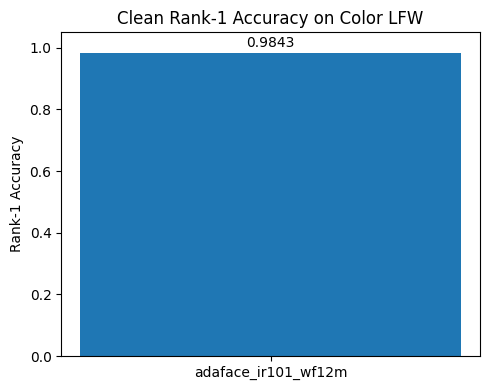

Saved: /content/face_auth_robustness_results/exp01_clean_color_lfw/adaface_ir101_wf12m/figures/01_clean_correct_accept_rate.png


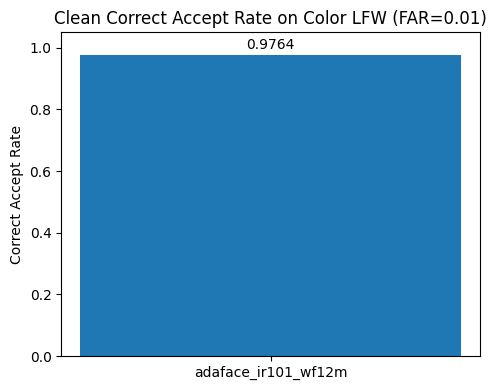

Saved: /content/face_auth_robustness_results/exp01_clean_color_lfw/adaface_ir101_wf12m/figures/01_clean_misaccept_rate.png


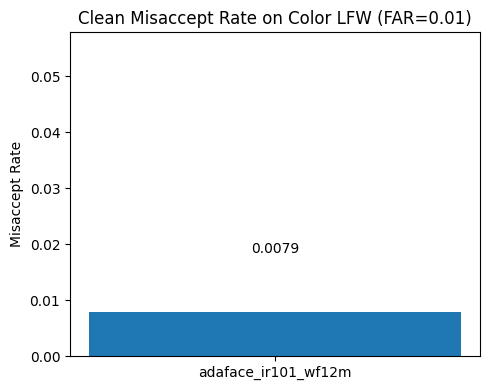

In [12]:
# ============================================================
# 12. Visualization
# ============================================================
# - 발표용 단일 모델 bar plot 저장
# - top-4 모델 비교 그래프는 모델별 summary CSV를 합친 뒤 별도 생성 권장

def save_single_bar(metric_name, value, title, ylabel, filename, ylim=None):
    """단일 metric bar plot 저장."""

    plt.figure(figsize=(5, 4))

    plt.bar([MODEL_SHORT_NAME], [value])
    plt.ylabel(ylabel)
    plt.title(title)

    plt.text(
        0,
        value + 0.01,
        f"{value:.4f}" if isinstance(value, float) else str(value),
        ha="center",
        va="bottom",
        fontsize=10,
    )

    if ylim is not None:
        plt.ylim(*ylim)

    plt.tight_layout()

    out_path = FIG_DIR / filename
    plt.savefig(out_path, dpi=200, bbox_inches="tight")

    print("Saved:", out_path)
    plt.show()


save_single_bar(
    "rank1_acc",
    metrics["rank1_acc"],
    "Clean Rank-1 Accuracy on Color LFW",
    "Rank-1 Accuracy",
    "01_clean_rank1_accuracy.png",
    ylim=(0, 1.05),
)

save_single_bar(
    "correct_accept_rate",
    metrics["correct_accept_rate"],
    f"Clean Correct Accept Rate on Color LFW (FAR={TARGET_FAR})",
    "Correct Accept Rate",
    "01_clean_correct_accept_rate.png",
    ylim=(0, 1.05),
)

save_single_bar(
    "misaccept_rate",
    metrics["misaccept_rate"],
    f"Clean Misaccept Rate on Color LFW (FAR={TARGET_FAR})",
    "Misaccept Rate",
    "01_clean_misaccept_rate.png",
    ylim=(0, max(0.05, metrics["misaccept_rate"] + 0.05)),
)

## Interpretation Memo

이 실험은 color=True LFW 기준 clean baseline이다.

발표에서 사용할 포인트는 다음과 같다.

1. 흑백이 아니라 컬러 얼굴 이미지로 실험 환경을 다시 구성했다.
2. Enrollment image로 identity DB를 만들고, probe image를 identification → verification 구조로 평가했다.
3. Threshold는 impostor similarity 분포에서 FAR 기준으로 설정했다.
4. 이후 adversarial sticker 실험은 clean 상태에서 올바르게 accept된 probe subset을 기준으로 진행한다.
5. 따라서 공격 성공률은 clean 상태에서도 실패하던 샘플을 포함하지 않고, 실제 인증이 잘 되던 샘플이 공격으로 얼마나 무너지는지를 보여준다.

다음 실험에서는 `01_clean_eval_indices.csv`에 포함된 probe subset을 사용하여 일반 스티커와 adversarial sticker를 비교한다.